# EDA

In [1]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
from glob import glob
from skimage.measure import label, regionprops
import seaborn as sns
import pandas as pd
import random
from skimage import exposure  


sns.set(style='whitegrid')

In [2]:
BASE_DIR = "/kaggle/input/recodai-luc-scientific-image-forgery-detection"
train_image_paths = sorted(glob(os.path.join(BASE_DIR, "train_images", "*", "*.png")))
train_mask_paths = sorted(glob(os.path.join(BASE_DIR, "train_masks", "*.npy")))
test_image_paths = sorted(glob(os.path.join(BASE_DIR, "test_images", "*", "*.png")))
print(f"Train images: {len(train_image_paths)}, Train masks: {len(train_mask_paths)}")
print(f"Test images: {len(test_image_paths)}")

Train images: 5128, Train masks: 2751
Test images: 0


In [3]:
def get_id(path):
    return os.path.splitext(os.path.basename(path))[0]

mask_map = {get_id(p): p for p in train_mask_paths}

In [4]:
pairs = []
for img_path in train_image_paths:
    cid = get_id(img_path)
    if cid in mask_map:
        mask_path = mask_map[cid]
        has_forgery = True
    else:
        mask_path = None
        has_forgery = False
    pairs.append({"img_path": img_path, "mask_path": mask_path, "has_forgery": has_forgery})

In [5]:
total_train = len(pairs)
forged_count = sum(p['has_forgery'] for p in pairs)
authentic_count = total_train - forged_count
auth_ratio = authentic_count / total_train if total_train > 0 else 0

print(f"Total train images: {total_train}")
print(f"Forged images: {forged_count} ({forged_count / total_train:.2%})")
print(f"Authentic images: {authentic_count} ({auth_ratio:.2%})")

Total train images: 5128
Forged images: 5128 (100.00%)
Authentic images: 0 (0.00%)


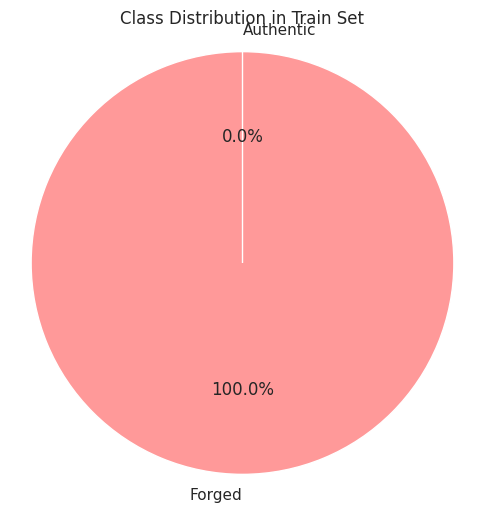

In [6]:
labels = ['Forged', 'Authentic']
sizes = [forged_count, authentic_count]
colors = ['#ff9999', '#66b3ff']
plt.figure(figsize=(6, 6))
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
plt.title('Class Distribution in Train Set')
plt.axis('equal')
plt.show()

In [7]:
def load_mask(mask_path, img_shape):
    H, W = img_shape[:2]
    if H == 0 or W == 0:
        return np.zeros((0, 0), dtype=np.uint8)
    if mask_path is None:
        return np.zeros((H, W), dtype=np.uint8)
    try:
        mask = np.load(mask_path)
    except Exception as e:
        print(f"Error loading mask {mask_path}: {e}")
        return np.zeros((H, W), dtype=np.uint8)
    if mask.size == 0:
        return np.zeros((H, W), dtype=np.uint8)
    if mask.ndim == 1 or mask.size != H * W:
        return np.zeros((H, W), dtype=np.uint8)
    else:
        try:
            mask = mask.reshape((H, W))
        except:
            return np.zeros((H, W), dtype=np.uint8)
    mask = (mask > 0).astype(np.uint8)
    return mask

In [8]:
fg_ratios = []
n_components = []
image_shapes = []  # (H, W, C)
is_grayscale = []    
mean_intensity = []   

for p in pairs:
    img = cv2.imread(p["img_path"])
    if img is None or img.shape[0] == 0 or img.shape[1] == 0:
        continue
    image_shapes.append(img.shape)
    
  
    if len(img.shape) == 2 or np.all(img[:,:,0] == img[:,:,1]) and np.all(img[:,:,1] == img[:,:,2]):
        is_grayscale.append(True)
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    else:
        is_grayscale.append(False)
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    

    mean_intensity.append(np.mean(gray))
    
    if p["has_forgery"]:
        mask = load_mask(p["mask_path"], img.shape)
        fg_ratios.append(mask.mean())
        labeled = label(mask)
        props = regionprops(labeled)
        n_components.append(len(props))


df_stats = pd.DataFrame({
    'Foreground Ratio': fg_ratios,
    'Num Components': n_components
})
print("\nSummary Stats for Forged Images:")
print(df_stats.describe())


Summary Stats for Forged Images:
       Foreground Ratio  Num Components
count       5128.000000     5128.000000
mean           0.043223        1.493955
std            0.067422        1.093789
min            0.000000        0.000000
25%            0.000000        0.000000
50%            0.009650        2.000000
75%            0.066881        2.000000
max            0.522728        5.000000


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


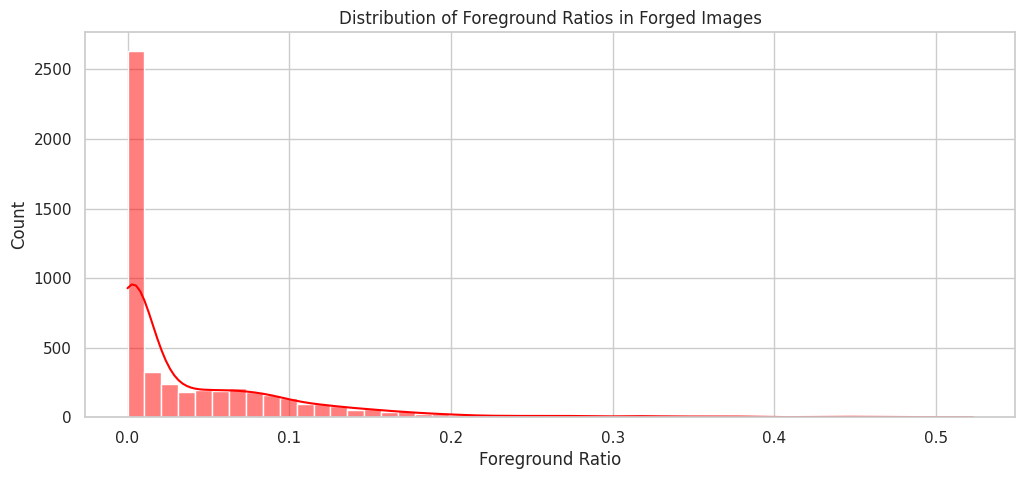

In [9]:
plt.figure(figsize=(12, 5))
sns.histplot(fg_ratios, bins=50, kde=True, color='red')
plt.title("Distribution of Foreground Ratios in Forged Images")
plt.xlabel("Foreground Ratio")
plt.ylabel("Count")
plt.show()



/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


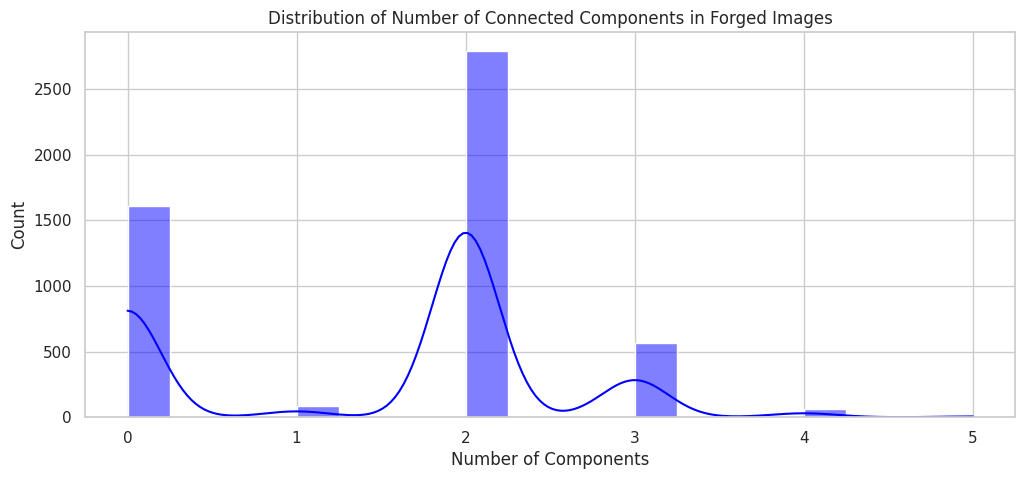

In [10]:
#  num components
plt.figure(figsize=(12, 5))
sns.histplot(n_components, bins=20, kde=True, color='blue')
plt.title("Distribution of Number of Connected Components in Forged Images")
plt.xlabel("Number of Components")
plt.ylabel("Count")
plt.show()



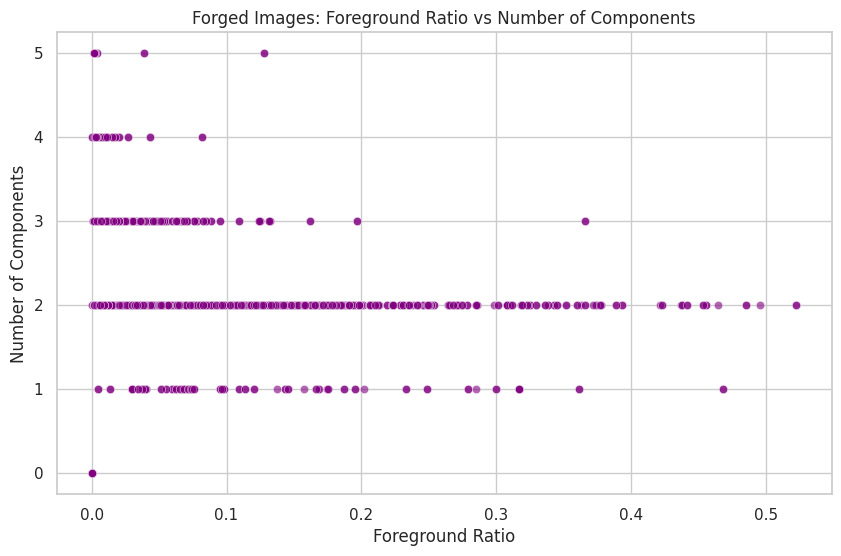

In [11]:
# Scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x=fg_ratios, y=n_components, alpha=0.6, color='purple')
plt.xlabel("Foreground Ratio")
plt.ylabel("Number of Components")
plt.title("Forged Images: Foreground Ratio vs Number of Components")
plt.show()

In [12]:
def get_shapes(paths):
    shapes = []
    for path in paths:
        img = cv2.imread(path)
        if img is not None:
            shapes.append(img.shape[:2])  # (H, W)
    return shapes

train_shapes = get_shapes(train_image_paths)
test_shapes = get_shapes(test_image_paths)


df_train_shapes = pd.DataFrame(train_shapes, columns=['Height', 'Width'])
df_test_shapes = pd.DataFrame(test_shapes, columns=['Height', 'Width'])

print("\nTrain Image Shapes Summary:")
print(df_train_shapes.describe())
print("\nTest Image Shapes Summary:")
print(df_test_shapes.describe())


Train Image Shapes Summary:
            Height        Width
count  5128.000000  5128.000000
mean    692.641576   930.980109
std     678.917187   729.418964
min      64.000000    74.000000
25%     256.000000   400.500000
50%     512.000000   696.000000
75%     706.000000  1024.000000
max    3888.000000  3888.000000

Test Image Shapes Summary:
       Height Width
count       0     0
unique      0     0
top       NaN   NaN
freq      NaN   NaN


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


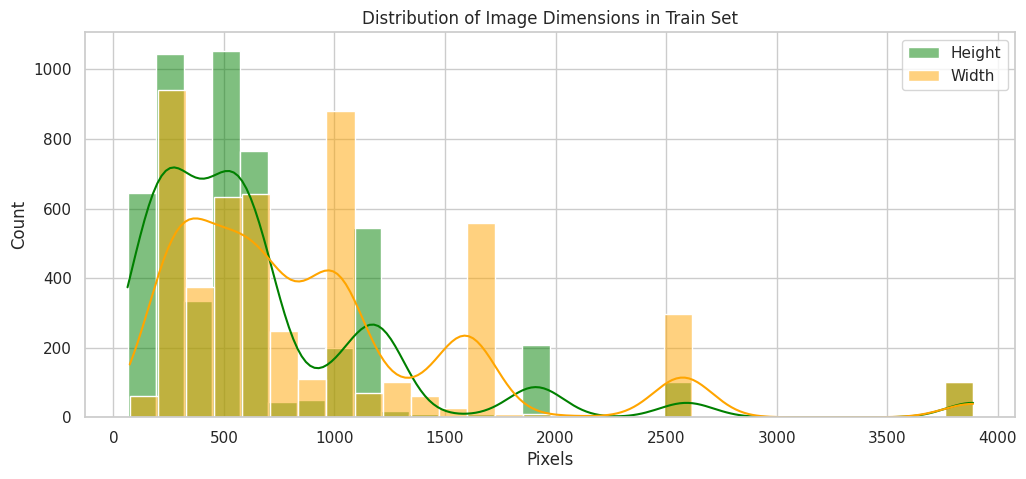

In [13]:
plt.figure(figsize=(12, 5))
sns.histplot(df_train_shapes['Height'], bins=30, kde=True, color='green', label='Height')
sns.histplot(df_train_shapes['Width'], bins=30, kde=True, color='orange', label='Width')
plt.title("Distribution of Image Dimensions in Train Set")
plt.xlabel("Pixels")
plt.ylabel("Count")
plt.legend()
plt.show()



Grayscale images ratio: 46.61%


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


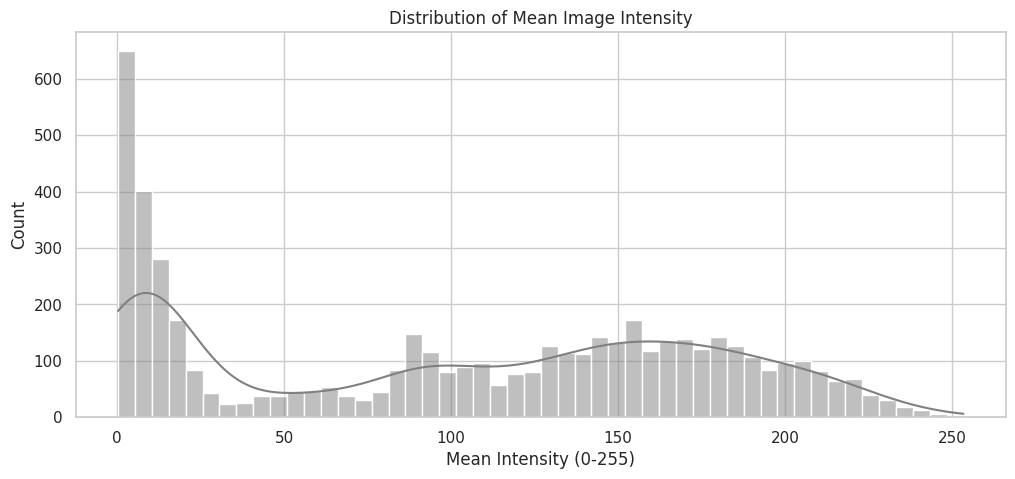

In [14]:
grayscale_ratio = sum(is_grayscale) / len(is_grayscale) if len(is_grayscale) > 0 else 0
print(f"Grayscale images ratio: {grayscale_ratio:.2%}")

plt.figure(figsize=(12, 5))
sns.histplot(mean_intensity, bins=50, kde=True, color='gray')
plt.title("Distribution of Mean Image Intensity")
plt.xlabel("Mean Intensity (0-255)")
plt.ylabel("Count")
plt.show()

In [15]:
def load_mask(mask_path, img_shape):
    H, W = img_shape[:2]
    if H == 0 or W == 0:
        return np.zeros((0, 0), dtype=np.uint8)
    if mask_path is None:
        return np.zeros((H, W), dtype=np.uint8)
    try:
        mask = np.load(mask_path)
    except:
        return np.zeros((H, W), dtype=np.uint8)
    if mask.size == 0:
        return np.zeros((H, W), dtype=np.uint8)
    if mask.ndim == 1 or mask.size != H * W:
        mask = np.zeros((H, W), dtype=np.uint8)
    else:
        try:
            mask = mask.reshape((H, W))
        except:
            mask = np.zeros((H, W), dtype=np.uint8)
    mask = (mask > 0).astype(np.uint8)
    return mask

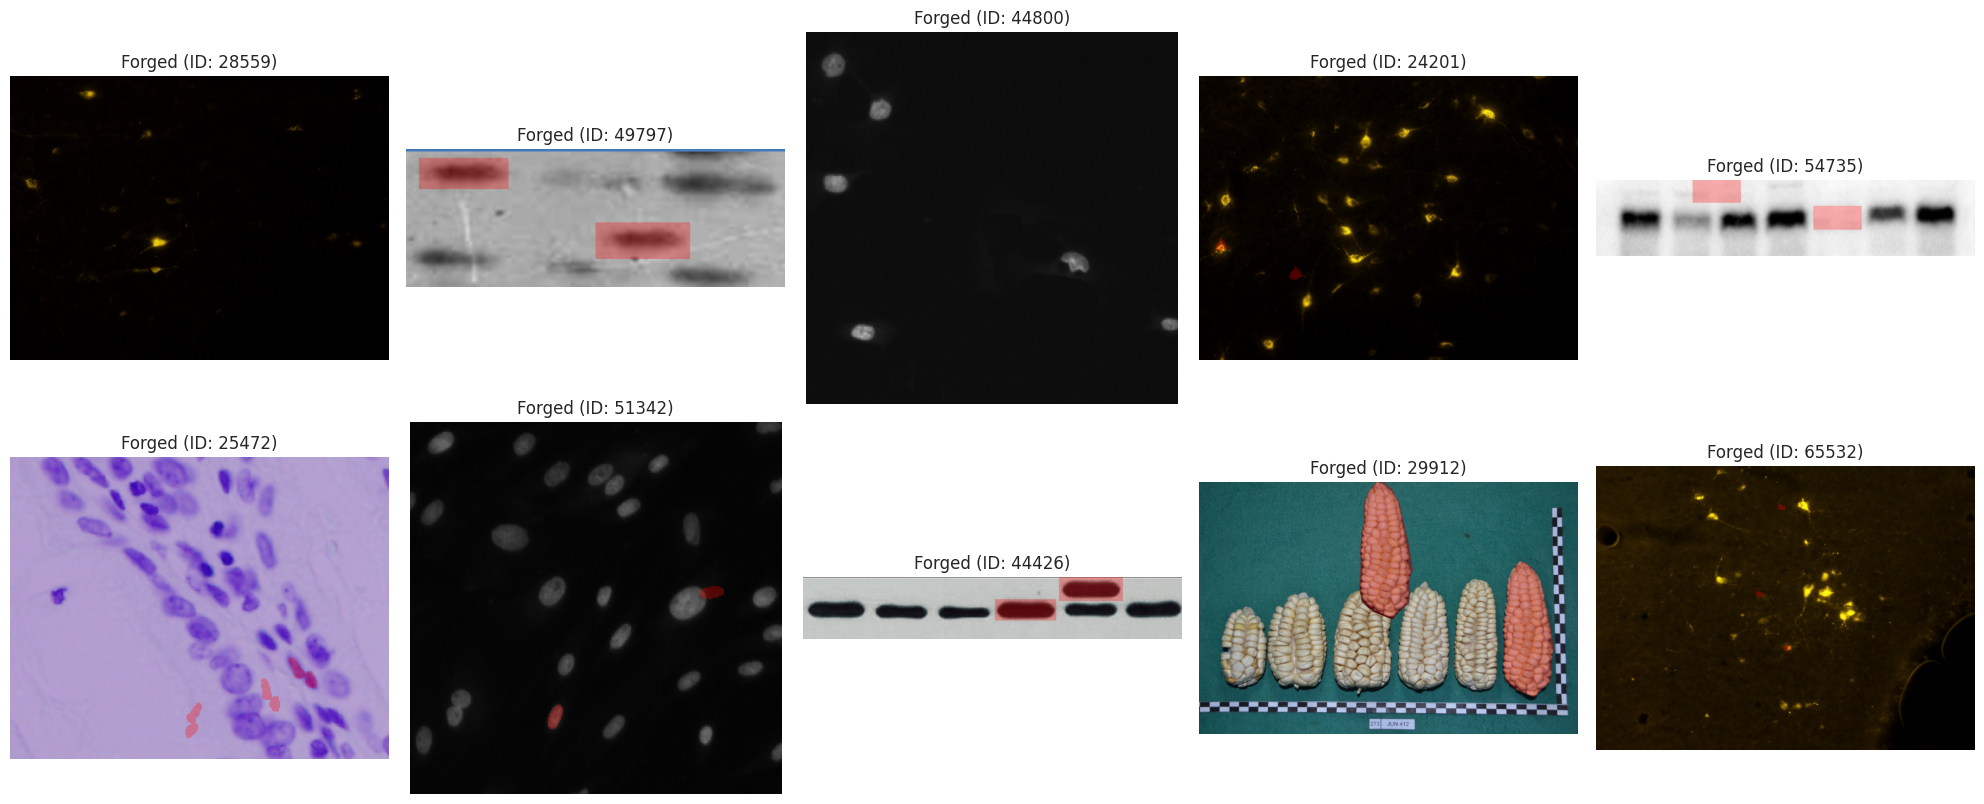

In [16]:
def show_samples(pairs, n=20):
    forged_samples = [p for p in pairs if p["has_forgery"]]
    authentic_samples = [p for p in pairs if not p["has_forgery"]]
    
    # Random sample
    forged_selected = random.sample(forged_samples, min(n//2, len(forged_samples)))
    authentic_selected = random.sample(authentic_samples, min(n//2, len(authentic_samples)))
    
    samples = forged_selected + authentic_selected
    random.shuffle(samples)  # shuffle برای تنوع
    
    rows = (n + 4) // 5  # 5 در هر ردیف
    plt.figure(figsize=(20, 4 * rows))
    for i, p in enumerate(samples):
        img = cv2.imread(p["img_path"])
        if img is None:
            continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        mask = load_mask(p["mask_path"], img.shape)
        img_to_show = img.copy()
        if p["has_forgery"]:
            overlay = img.copy()
            overlay[mask == 1] = [255, 0, 0]  # red overlay
            img_to_show = cv2.addWeighted(img, 0.7, overlay, 0.3, 0)
        plt.subplot(rows, 5, i + 1)
        plt.imshow(img_to_show)
        plt.axis("off")
        plt.title(f"{'Forged' if p['has_forgery'] else 'Authentic'} (ID: {get_id(p['img_path'])})")
    plt.tight_layout()
    plt.show()

show_samples(pairs, n=20)

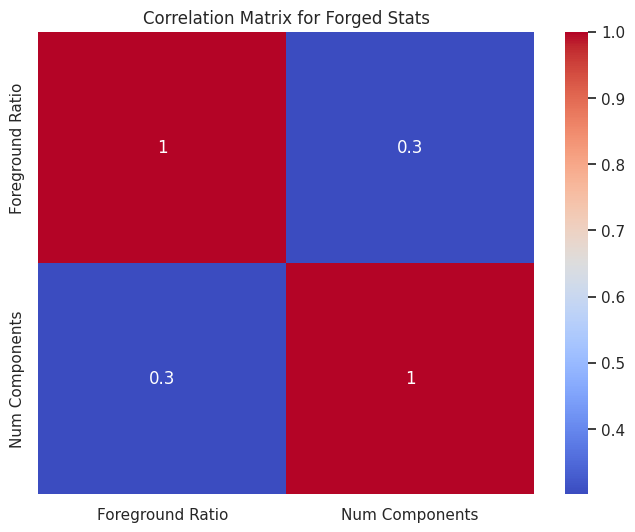

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


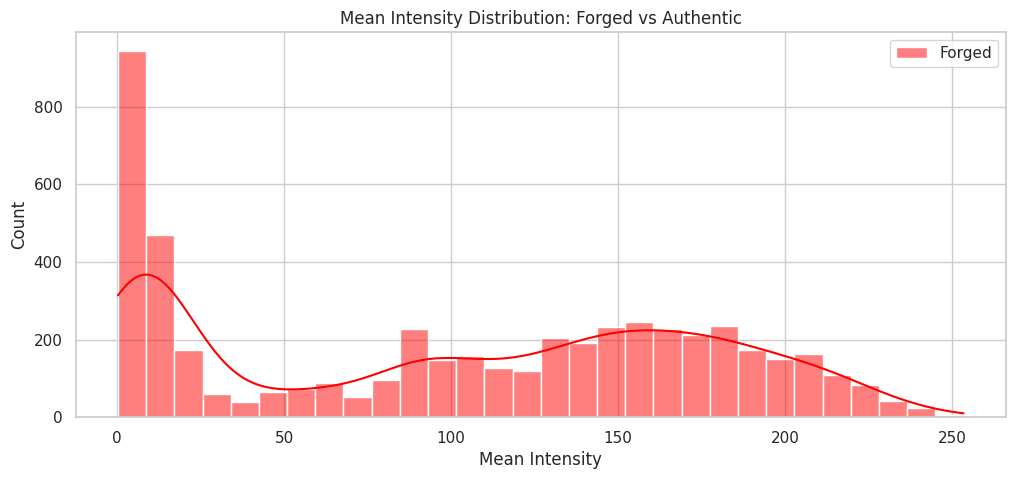

EDA Complete! This provides a strong foundation for model development.


In [17]:
corr_matrix = df_stats.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix for Forged Stats")
plt.show()


forged_intensity = [mean_intensity[i] for i, p in enumerate(pairs) if p["has_forgery"]]
authentic_intensity = [mean_intensity[i] for i, p in enumerate(pairs) if not p["has_forgery"]]

plt.figure(figsize=(12, 5))
sns.histplot(forged_intensity, bins=30, kde=True, color='red', label='Forged')
sns.histplot(authentic_intensity, bins=30, kde=True, color='blue', label='Authentic')
plt.title("Mean Intensity Distribution: Forged vs Authentic")
plt.xlabel("Mean Intensity")
plt.ylabel("Count")
plt.legend()
plt.show()

print("EDA Complete! This provides a strong foundation for model development.")